In [1]:
using Pkg
    Pkg.activate(".")
using PsfUnmixing, LinearAlgebra,  LaTeXStrings, Measures, Random


  Activating project at `~/PsfUnmixing`


In [2]:
function block_diag_matrices(matrices::Vector{<:AbstractMatrix})
    total_rows = sum(size.(matrices, 1))
    total_cols = sum(size.(matrices, 2))
    result = zeros(eltype(first(matrices)), total_rows, total_cols)

    row_start = 1
    col_start = 1
    for mat in matrices
        rows, cols = size(mat)
        result[row_start:row_start+rows-1, col_start:col_start+cols-1] .= mat
        row_start += rows
        col_start += cols
    end

    return result
end

block_diag_matrices (generic function with 1 method)

In [3]:
u = 2 # naturalized gaussian kernel

s_min = 1e-3
s_max = 1e-2

θ_min = s_laplace(s_min, u, s_min)
θ_max = s_laplace(s_max, u, s_min) 

k_0(θ, t) = laplace_0_n(θ, t, u, umin=s_min)
k_1(θ, t) = laplace_1_n(θ, t, u, umin=s_min)
k_2(θ, t) = laplace_2_n(θ, t, u, umin=s_min)
k_3(θ, t) = laplace_3_n(θ, t, u, umin=s_min)

k_3 (generic function with 1 method)

In [4]:
function residual(θ, η, x_obs, dictionary, xgrid) 
    @assert length(dictionary) == length(θ) # should be p
    @assert sum(length.(dictionary)) == length(η) #should be p*d
    @assert length(x_obs) == length(xgrid) # just to be same
    A = multi_block(k_0, θ, dictionary, xgrid) # we don change the xgrid or the kernel
    return x_obs - A * η
end

residual (generic function with 1 method)

In [5]:
# hessian, full problem

function hessian(θ, η, x_obs, dictionary, xgrid)

    @assert length(dictionary) == length(θ) # should be p
    @assert sum(length.(dictionary)) == length(η) #should be p*d
    @assert length(x_obs) == length(xgrid) # just to be same

    # once assertions are done we can get sizes
    d = length(dictionary[1]) 
    p = length(θ)

    G0 = multi_block(k_0, θ, dictionary, xgrid)
    G1 = multi_block(k_1, θ, dictionary, xgrid)

    r = residual(θ, η, x_obs, dictionary, xgrid) 

    diag_eta = block_diag(collect(Iterators.partition(η, d)))

    # Curvature part
    ∇_θr = G1 * diag_eta
    ∇_ηr = G0

    C = vcat(hcat(transpose(∇_θr) * ∇_θr, transpose(∇_θr) * ∇_ηr),
             hcat(transpose(∇_ηr) * ∇_θr, transpose(∇_ηr) * ∇_ηr))

    # diagonal tensor flattened representation
    G1 = Vector{Matrix{Float64}}()
    G2 = Vector{Matrix{Float64}}()
    for (group, θ_i) in zip(dictionary, θ) # theta is univariate
        push!(G1, single_block(k_1, θ_i, group, xgrid))
        push!(G2, single_block(k_2, θ_i, group, xgrid))
    end

    # Residual part
    r∇_θr  =  transpose(kron(I(p), r)) * block_diag_matrices(G2) * diag_eta
    r∇_ηθr =  transpose(block_diag_matrices(G1)) * kron(I(p), r)

    R = vcat(hcat(r∇_θr, transpose(r∇_ηθr)), hcat(r∇_ηθr, zeros(d*p, d*p)))

    return C - R
end

hessian (generic function with 1 method)

In [6]:
function jacobian(θ, η, dictionary, xgrid)

    @assert length(dictionary) == length(θ) # should be p
    @assert sum(length.(dictionary)) == length(η) #should be p*d

    # once assertions are done we can get sizes
    d = length(dictionary[1]) 

    G0 = multi_block(k_0, θ, dictionary, xgrid)
    G1 = multi_block(k_1, θ, dictionary, xgrid)
    diag_eta = block_diag(collect(Iterators.partition(η, d)))

    return hcat(G1 * diag_eta, G0)
end

jacobian (generic function with 1 method)

In [7]:
using Random

function random_perturbation(
	θ_star,
	η_star,
	σ_1,
	σ_2,
    ϵ;
	rng = Random.default_rng(),
)
	dθ = randn(rng, length(θ_star))
	dη = randn(rng, length(η_star))
	finsler_norm = (σ_2*norm(η_star, 2) + σ_1) * norm(dθ, 2) + σ_1 * norm(dη, 2)
	dθ ./= finsler_norm
	dη ./= finsler_norm
	return θ_star + ϵ * dθ, η_star + ϵ * dη
end


random_perturbation (generic function with 1 method)

In [8]:
function monte_carlo_extr_spectrum(M, θ_star, η_star, σ_1, σ_2,  ϵ; trials=100)
    σ_min = Inf
    σ_max = - Inf
    for _ in 1:trials
        θ, η = random_perturbation(θ_star, η_star, σ_1, σ_2,  ϵ)
        G = M(θ, η)
        if size(G)[1] == size(G)[2]
            eigvals_ = eigvals(Hermitian(G))
            σ_min = min(σ_min, minimum(eigvals_))
            σ_max = max(σ_max, maximum(eigvals_))
        else
            svals = svdvals(G)
            σ_min = min(σ_min, minimum(svals))
            σ_max = min(σ_max, minimum(svals))
        end
    end
    return σ_max, σ_min
end

function monte_carlo_envelope(M, θ_star, η_star, σ_1, σ_2,  ϵ; trials=100)
    σ_max = -Inf
    M_star = M(θ_star, η_star)
    for _ in 1:trials
        θ, η = random_perturbation(θ_star, η_star, σ_1, σ_2,  ϵ)
        E = M_star - M(θ, η)
        σ_max = max(σ_max, opnorm(E))
    end
    return σ_max
end


monte_carlo_envelope (generic function with 1 method)

In [9]:
function lipschitz_constant(k, dictionary, xgrid)
    θ_range = range(θ_min, θ_max, length=100)
    opnorms = zeros(Float64, length(θ_range), length(dictionary))
    for (i, θ) in enumerate(θ_range)
        for (j ,group) in enumerate(dictionary)
           opnorms[i,j] = opnorm(single_block(k, θ, group, xgrid)) 
        end
    end
    return maximum(opnorms)
end

lipschitz_constant (generic function with 1 method)

In [10]:
using Random
rng = MersenneTwister(0)

MersenneTwister(0)

In [73]:
function basin_data_ranges(
	θ_min,
	θ_max,
	ϵ_min,
	ϵ_max,
	p_range,
	d_range,
	k_0,
	k_1,
	k_2,
	k_3;
	N = 1000,
	T = 1.0,
	Δ = 0.1,
	N_mc = 100,
	mc_trials = 1000,
)

	xgrid = range(-T, T, length = N)
	ϵ = logrange(ϵ_min, ϵ_max, length = N_mc)

	out = Dict{Tuple{Int, Int}, Any}()
	for (p, d) in Iterators.product(p_range, d_range)
		θ_star = 0.5 * (θ_min + θ_max) * ones(p) # always midpoint
		η_star = ones(p*d)

		dictionary = generate_spike_groups(rng, -T, T, Δ, p, d)

		x_obs = multi_block(k_0, θ_star, dictionary, xgrid) * η_star

		σ_0 = sqrt(p) * lipschitz_constant(k_0, dictionary, xgrid)
		σ_1 = lipschitz_constant(k_1, dictionary, xgrid)
		σ_2 = lipschitz_constant(k_2, dictionary, xgrid)
		σ_3 = lipschitz_constant(k_3, dictionary, xgrid)


		c_star_functional(θ, group) = begin
			return opnorm(single_block(k_2, θ, group, xgrid)) * norm(η_star, 2) +
				   2 * opnorm(single_block(k_1, θ, group, xgrid))
		end

		c_star = maximum([
			c_star_functional(θ_star[i], dictionary[i]) for
			i in eachindex(θ_star)
		])

		c_r_1 = max(σ_0/(σ_2*norm(η_star, 2) + σ_1), inv(norm(η_star, 2)))

		c_r_2 = max(
			(σ_3*norm(η_star, 2) + 2*σ_2)/(σ_2*norm(η_star, 2) + σ_1),
			2*σ_2/norm(η_star, 2),
		)

		J_star = opnorm(jacobian(θ_star, η_star, dictionary, xgrid))

		μ_min = minimum(
			eigvals(
				Hermitian(hessian(θ_star, η_star, x_obs, dictionary, xgrid)),
			),
		)
		μ_max = maximum(
			eigvals(
				Hermitian(hessian(θ_star, η_star, x_obs, dictionary, xgrid)),
			),
		)

		println("p,d = $(p),$(d), μ_min = $(μ_min), μ_max = $(μ_max)")

		H(θ, η) = hessian(θ, η, x_obs, dictionary, xgrid)

		min_eigval          = zeros(N_mc)
		max_eigval          = zeros(N_mc)
		envelope            = zeros(N_mc)
		analytical_envelope = zeros(N_mc)
		for (i, δ) in enumerate(ϵ)
			max_eigval[i], min_eigval[i] = monte_carlo_extr_spectrum(H, θ_star, η_star, σ_1, σ_2, δ; trials = mc_trials)
			envelope[i]                  = monte_carlo_envelope(H, θ_star, η_star, σ_1, σ_2, δ; trials = mc_trials)
			analytical_envelope[i]       = (c_star * c_r_1 + 2 * J_star) * δ + c_r_1 * c_r_2 * δ^2
		end

		finsler_norm =
			(σ_2*norm(η_star, 2) + σ_1) * norm(θ_star, 2) +
			σ_1 * norm(η_star, 2)

		out[(p, d)] = (
			x          = ϵ ./ finsler_norm,
			min_eigval = min_eigval,
			lower_weyl = μ_min .- envelope,
			lower_env  = μ_min .- analytical_envelope,
		)
	end
	return out
end


basin_data_ranges (generic function with 1 method)

In [109]:
p_range = [2, 5]
d_range = [1, 5]
full_hessian_basins = basin_data_ranges(
	θ_min,
	θ_max,
	1e-4,
	1e3,
	p_range,
	d_range,
	k_0,
	k_1,
	k_2,
	k_3,
	T = 1.0,
	N_mc = 100,
	mc_trials = 100,
	Δ = 5e-3,
);


p,d = 2,1, μ_min = 0.89215899967008, μ_max = 683.1986621330952
p,d = 5,1, μ_min = 0.8921589708285017, μ_max = 683.1986565095601
p,d = 2,5, μ_min = 1.309228215710237, μ_max = 2902.228715803495
p,d = 5,5, μ_min = 1.301715218575521, μ_max = 3006.6808697620118


In [13]:
signed_log(x) = sign(x) * log10(1 + abs(x))

signed_log (generic function with 1 method)

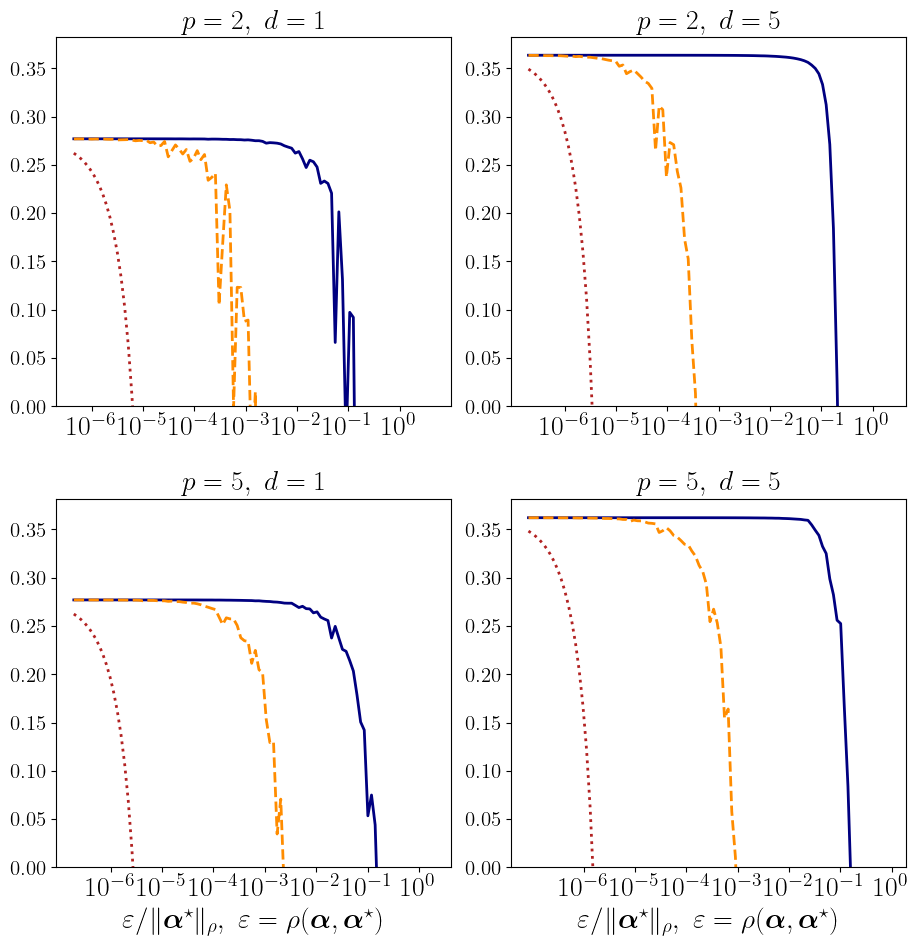

In [ ]:
using PyPlot
using LaTeXStrings

PyPlot.rc("text", usetex=true)
PyPlot.rc("font", family="serif")
PyPlot.rc("text.latex", preamble = raw"\usepackage{amsmath,amssymb,bm}")

plots = []

max_y = maximum([maximum(full_hessian_basins[(p,d)].min_eigval) for (p,d) in Iterators.product(p_range, d_range)])
ymax  = log10(max_y + 1.1)

fig, axs = subplots(2, 2, figsize=(10, 10), constrained_layout=false)
axs = vec(axs)

i = 0
for (p, d) in Iterators.product(p_range, d_range)
    B = full_hessian_basins[(p,d)]
    i += 1
    ax = axs[i]

    ax.set_xscale("log")
    ax.set_ylim(0.0, ymax)
    ax.set_xticks([1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 1e0])

    show_legend = (p == last(p_range) && d == first(d_range))

    ax.plot(B.x, signed_log.(B.min_eigval);
        linestyle="-", color="navy", linewidth=2,
        label = show_legend ? L"\lambda_{\min}(\bm{H}(\bm{\alpha}))" : ""
    )

    ax.plot(B.x, signed_log.(B.lower_weyl);
        linestyle="--", color="darkorange", linewidth=2,
        label = show_legend ? L"\xi^\star - \|\bm{H}(\bm{\alpha})-\bm{H}(\bm{\alpha}^\star)\|" : ""
    )

    ax.plot(B.x, signed_log.(B.lower_env);
        linestyle=":", color="firebrick", linewidth=2,
        label = show_legend ? L"\xi^\star - c_{1}(\bm{\alpha}^\star)\varepsilon - c_{2}(\bm{\alpha}^\star)\varepsilon^2" : ""
    )

    if p == last(p_range)
        ax.set_xlabel(L"\varepsilon/\|\bm{\alpha}^\star\|_\rho,\ \varepsilon=\rho(\bm{\alpha},\bm{\alpha}^\star)", fontsize=20)
    end

    # if show_legend
    #     ax.legend(loc="lower left", fontsize=15, frameon=true)
    # end

    ax.set_title(L"p=%$p,\ d=%$d", fontsize=20)

    ax.tick_params(axis="x", labelsize=20)
    ax.tick_params(axis="y", labelsize=15)

end

fig.subplots_adjust(left=0.13, right=0.98, bottom=0.12, top=0.95, wspace=0.15, hspace=0.2)

savefig("figures/tsp_full_envelopes.pdf", bbox_inches="tight")
fig


In [98]:
using Statistics, ProgressMeter

function basin_data_ranges_noisy_db(
	θ_min, θ_max, ϵ_min, ϵ_max, pd_list, k_0, k_1, k_2, k_3;
	N = 1000, T = 1.0, Δ = 0.1, N_mc = 100, mc_trials = 1000,
	snr_db::Real = 30.0,
	realizations::Int = 10,
	noise_seed::Int = 1,
	rng = Random.default_rng(),
)
	xgrid = range(-T, T, length = N)
	ϵ = logrange(ϵ_min, ϵ_max, length = N_mc)

	out = Dict{Tuple{Int, Int}, Any}()

	@showprogress for (p, d) in pd_list
		θ_star = 0.5 * (θ_min + θ_max) * ones(p)
		η_star = ones(p*d)

		dictionary = generate_spike_groups(rng, -T, T, Δ, p, d)
		x_obs_clean = multi_block(k_0, θ_star, dictionary, xgrid) * η_star

		σ_0 = sqrt(p) * lipschitz_constant(k_0, dictionary, xgrid)
		σ_1 = lipschitz_constant(k_1, dictionary, xgrid)
		σ_2 = lipschitz_constant(k_2, dictionary, xgrid)
		σ_3 = lipschitz_constant(k_3, dictionary, xgrid)

		c_star_functional(θ, group) =
			opnorm(single_block(k_2, θ, group, xgrid)) * norm(η_star, 2) +
			2 * opnorm(single_block(k_1, θ, group, xgrid))

		c_star = maximum(
			c_star_functional(θ_star[i], dictionary[i])
			for i in eachindex(θ_star)
		)

		c_r_1 = max(σ_0/(σ_2*norm(η_star, 2) + σ_1), inv(norm(η_star, 2)))
		c_r_2 = max((σ_3*norm(η_star, 2) + 2*σ_2)/(σ_2*norm(η_star, 2) + σ_1),
			2*σ_2/norm(η_star, 2))

		J_star = opnorm(jacobian(θ_star, η_star, dictionary, xgrid))

		finsler_norm =
			(σ_2*norm(η_star, 2) + σ_1) * norm(θ_star, 2) +
			σ_1 * norm(η_star, 2)

		x = ϵ ./ finsler_norm

		μmins         = zeros(realizations)
		min_eigs       = zeros(realizations, N_mc)
		envelopes      = zeros(realizations, N_mc)
		analytical_env = zeros(realizations, N_mc)

		for r in 1:realizations
			rng_noise = MersenneTwister(noise_seed + r + 10_000*p + d)

			w_dir = randn(rng_noise, length(x_obs_clean))
			w_dir ./= norm(w_dir)

			w_norm = norm(x_obs_clean) * 10.0^(-snr_db/20.0)
			w = w_norm * w_dir

			x_obs_noisy = x_obs_clean + w

			H_noisy(θ, η) =
				hessian(θ, η, x_obs_noisy, dictionary, xgrid)

			μmins[r] =
				minimum(
					eigvals(
						Hermitian(
							hessian(
								θ_star,
								η_star,
								x_obs_noisy,
								dictionary,
								xgrid,
							),
						),
					),
				)

			for (i, δ) in enumerate(ϵ)
				_, min_eigs[r, i] =
					monte_carlo_extr_spectrum(
						H_noisy, θ_star, η_star, σ_1, σ_2, δ;
						trials = mc_trials,
					)

				envelopes[r, i] =
					monte_carlo_envelope(
						H_noisy, θ_star, η_star, σ_1, σ_2, δ;
						trials = mc_trials,
					)

				analytical_env[r, i] =
					(c_star*c_r_1 + 2*J_star)*δ +
					((norm(w) + c_r_1)*c_r_2)*δ^2
			end
		end

		lower_env            = μmins .- envelopes
		lower_env_analytical = μmins .- analytical_env

		out[(p, d)] = (
			x = x, 
			μ_min_noisy_mean = mean(μmins),
			μ_min_noisy_std  = std(μmins),
			min_eigval_noisy_mean = vec(mean(min_eigs, dims = 1)),
			min_eigval_noisy_std  = vec(std(min_eigs, dims = 1)),
			lower_env_noisy_mean = vec(mean(lower_env, dims = 1)),
			lower_env_noisy_std  = vec(std(lower_env, dims = 1)),
			lower_env_analytical_noisy_mean =
			vec(mean(lower_env_analytical, dims = 1)),
			lower_env_analytical_noisy_std  =
			vec(std(lower_env_analytical, dims = 1)),
		)
	end

	return out
end


basin_data_ranges_noisy_db (generic function with 1 method)

In [114]:
pd_list = [(2,1), (5,5)]
noisy_full_hessian_basins = basin_data_ranges_noisy_db(
    θ_min, θ_max, 1e-4, 1e3, pd_list, k_0, k_1, k_2, k_3;
    snr_db = 0.0, 
    noise_seed = 1,
    N_mc = 100,
    mc_trials = 100,
    realizations = 10,
    Δ = 5e-3
);

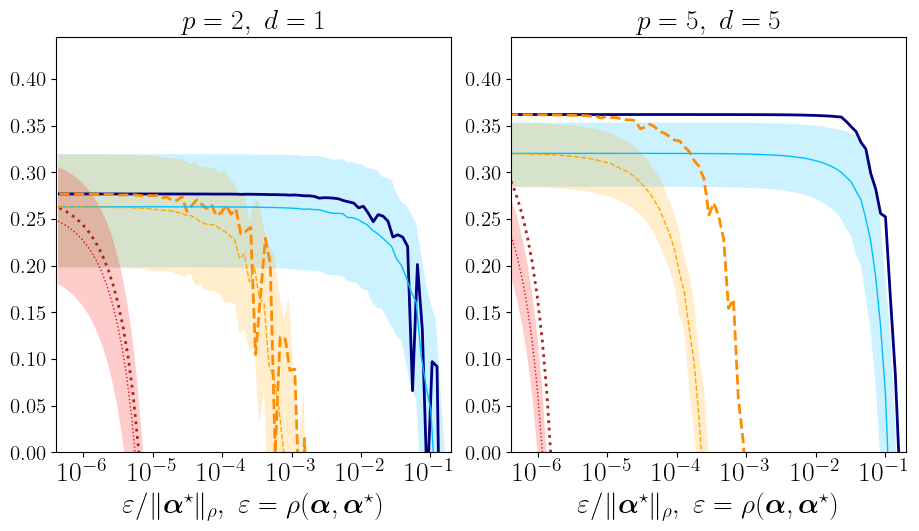

In [126]:

# LaTeX + bm (for \bm)
PyPlot.rc("text", usetex=true)
PyPlot.rc("font", family="serif")
PyPlot.rc("text.latex", preamble = raw"\usepackage{amsmath,amssymb,bm}")

max_y = maximum([maximum(basins[(p,d)].min_eigval_noisy_mean) for (p,d) in pd_list])
ymax  = log10(max_y + 1.5)

# assumes you already have:
# signed_log.(...) available
# basins[(p,d)] now contains only noisy means/stds:
#   B.x
#   B.min_eigval_noisy_mean, B.min_eigval_noisy_std
#   B.lower_env_noisy_mean,  B.lower_env_noisy_std
#   B.lower_env_analytical_noisy_mean, B.lower_env_analytical_noisy_std
#   (optional) B.snr_db_mean

fig, axs = subplots(1, length(pd_list), figsize=(10,5), constrained_layout=false)
axs = length(pd_list) == 1 ? [axs] : vec(axs)

for (idx, (p,d)) in enumerate(pd_list)
    B       = full_hessian_basins[(p,d)]
    B_noisy = noisy_full_hessian_basins[(p,d)]
    ax = axs[idx]
    show_legend = (idx == 1)

    ax.set_xscale("log")
    ax.set_ylim(0.0, ymax)
    ax.set_xlim(4e-7, 2e-1)
    ax.set_xticks([1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1])
    ax.set_title(L"p=%$p,\ d=%$d", fontsize=9)

    # --- helper to plot mean + ribbon in signed_log domain ---
    function plot_mean_ribbon!(ax, x, m, s; color, ls, lw, label="")
        y  = signed_log.(m)
        yl = signed_log.(m .- s)
        yu = signed_log.(m .+ s)
        ax.plot(x, y; color=color, linestyle=ls, linewidth=lw, label=label)
        ax.fill_between(x, yl, yu; color=color, alpha=0.20, linewidth=0)
    end

    ax.plot(B.x, signed_log.(B.min_eigval);
        linestyle="-", color="navy", linewidth=2,
        label = show_legend ? L"\lambda_{\min}(\bm{H}(\bm{\alpha}))" : ""
    )

    ax.plot(B.x, signed_log.(B.lower_weyl);
        linestyle="--", color="darkorange", linewidth=2,
        label = show_legend ? L"\xi^\star - \|\bm{H}(\bm{\alpha})-\bm{H}(\bm{\alpha}^\star)\|" : ""
    )

    ax.plot(B.x, signed_log.(B.lower_env);
        linestyle=":", color="firebrick", linewidth=2,
        label = show_legend ? L"\xi^\star - c_{1}(\bm{\alpha}^\star)\varepsilon - c_{2}(\bm{\alpha}^\star)\varepsilon^2" : ""
    )

    # noisy (mean ± std ribbon)
    plot_mean_ribbon!(ax, B_noisy.x, B_noisy.min_eigval_noisy_mean, B_noisy.min_eigval_noisy_std;
        color="deepskyblue", ls="-",  lw=1,
    )
    plot_mean_ribbon!(ax, B_noisy.x, B_noisy.lower_env_noisy_mean, B_noisy.lower_env_noisy_std;
        color="orange", ls="--", lw=1,
    )
    plot_mean_ribbon!(ax, B_noisy.x, B_noisy.lower_env_analytical_noisy_mean, B_noisy.lower_env_analytical_noisy_std;
        color="red", ls=":", lw=1,
    )

    # x/y labels (same logic as your original)
    ax.set_xlabel(L"\varepsilon/\|\bm{\alpha}^\star\|_\rho,\ \varepsilon=\rho(\bm{\alpha},\bm{\alpha}^\star)", fontsize=20)

    ax.set_title(L"p=%$p,\ d=%$d", fontsize=20)

    ax.tick_params(axis="x", labelsize=20)
    ax.tick_params(axis="y", labelsize=15)

    # Put the SNR text once per subplot using built-in annotation
    if hasproperty(B, :snr_db_mean)
        snr_txt = L"\mathrm{SNR}=%$(round(B.snr_db_mean, digits=1))\ \mathrm{dB}"
        ax.text(0.03, 0.06, snr_txt; transform=ax.transAxes, fontsize=8)
    end

    # if show_legend
    #     ax.legend(loc="lower left", fontsize=15, frameon=true)
    # end
end

# figure sizing / dpi: dpi mainly matters for raster; PDF is vector
# fig.set_size_inches(7.16, 2.8)   # two-column-ish wide, short; tweak as you like
# fig.subplots_adjust(left=0.06, right=0.995, bottom=0.22, top=0.88, wspace=0.15)

fig.subplots_adjust(left=0.13, right=0.98, bottom=0.12, top=0.95, wspace=0.15)

savefig("figures/tsp_full_hessian_noisy_basin.pdf", bbox_inches="tight") # vector
# savefig("figures/tsp_full_hessian_noisy_basin.png", dpi=800, bbox_inches="tight")

display(fig)


In [36]:
# hessian, projected problem
function residual_vp(θ, x_obs, dictionary, xgrid) 
    @assert length(dictionary) == length(θ) # should be p
    @assert length(x_obs) == length(xgrid) # just to be same

    A = multi_block(k_0, θ, dictionary, xgrid) # we don change the xgrid or the kernel
    U, = svd(A)

    return x_obs - U * (transpose(U) * x_obs)
end

function hessian_vp(θ, x_obs, dictionary, xgrid)

    @assert length(dictionary) == length(θ) # should be p
    @assert length(x_obs) == length(xgrid) # just to be same

    # once assertions are done we can get sizes
    d = length(dictionary[1]) 
    p = length(θ)

    G0 = multi_block(k_0, θ, dictionary, xgrid)
    G1 = multi_block(k_1, θ, dictionary, xgrid)

    r = residual_vp(θ, x_obs, dictionary, xgrid)

    η = G0 \ x_obs

    diag_eta = block_diag(collect(Iterators.partition(η, d)))

    # Curvature part
    ∇_θr = G1 * diag_eta
    ∇_ηr = G0

    # diagonal tensor flattened representation
    G1_tensor = Vector{Matrix{Float64}}()
    G2 = Vector{Matrix{Float64}}()
    for (group, θ_i) in zip(dictionary, θ) # theta is univariate
        push!(G1_tensor, single_block(k_1, θ_i, group, xgrid))
        push!(G2, single_block(k_2, θ_i, group, xgrid))
    end

    # Residual part
    r∇_θr  = - transpose(kron(I(p), r)) * block_diag_matrices(G2) * diag_eta
    r∇_ηθr = - transpose(block_diag_matrices(G1_tensor)) * kron(I(p), r)

    ∇_θL  = transpose(∇_θr) * ∇_θr + r∇_θr
    ∇_ηθL = transpose(∇_ηr) * ∇_θr + r∇_ηθr 

    return ∇_θL - transpose(∇_ηθL) * inv(transpose(G0)*G0 + 1e-8*I) * ∇_ηθL
end

hessian_vp (generic function with 1 method)

In [37]:
function projected_perturbation(
	θ_star,
    ϵ;
	rng = Random.default_rng(),
)
	dθ = rand(rng, length(θ_star))
	return θ_star + ϵ * dθ ./ norm(dθ, 2)
end

function projected_enveleope(ϵ, norm_J_star, norm_DJ_star, noise_power, θ_star, η_star, k_0, x_obs, σ_0, σ_1, σ_2, σ_3, dictionary, xgrid; trials=100)
    max_pert = - Inf
    for _ in 1:trials
        θ_pert = projected_perturbation(θ_star, ϵ)
        η_pert = multi_block(k_0, θ_pert, dictionary, xgrid) \ x_obs
        t_1 = (σ_2 * norm(η_star, 2) + σ_1) * norm(θ_star - θ_pert, 2) + σ_1 * norm(η_star - η_pert, 2)
        t_2 = σ_1 * norm(η_star, 2) * norm(θ_star - θ_pert, 2) + σ_0 * norm(η_star - η_pert, 2)
        t_3 = (σ_3 * norm(η_star, 2) + 2σ_2) * norm(θ_star - θ_pert, 2) + 2σ_2 * norm(η_star - η_pert, 2)
        env = 2 * norm_J_star * t_1 + t_1^2 + norm_DJ_star * t_2 + (noise_power + t_2) * t_3
        max_pert = max(max_pert, env)
    end
	return max_pert
end


function monte_carlo_extr_spectrum_vp(M, θ_star, ϵ; trials=100)
    σ_min = Inf
    σ_max = -Inf
    for _ in 1:trials
        θ = projected_perturbation(θ_star, ϵ)
        G = M(θ)
        if size(G)[1] == size(G)[2]
            eigvals_ = eigvals(Hermitian(G))
            σ_min    = min(σ_min, minimum(eigvals_))
            σ_max    = max(σ_max, maximum(eigvals_))
        else
            svdvals_ = svdvals(G)
            σ_min    = min(σ_min, minimum(svdvals_))
            σ_max    = max(σ_max, maximum(svdvals_))
        end
    end
    return σ_max, σ_min
end

function monte_carlo_envelope_vp(M, θ_star, ϵ; trials=100)
    σ_max = -Inf
    M_star = M(θ_star)
    for _ in 1:trials
        θ = projected_perturbation(θ_star, ϵ)
        E = M_star - M(θ)
        σ_max = max(σ_max, opnorm(E))
    end
    return σ_max
end

monte_carlo_envelope_vp (generic function with 1 method)

In [128]:
function basin_data_ranges_vp(
	θ_min,
	θ_max,
	ϵ_min,
	ϵ_max,
	p_range,
	d_range,
	k_0,
	k_1,
	k_2,
	k_3;
	N = 1000,
	T = 1.0,
	Δ = 0.1,
	N_mc = 100,
	mc_trials = 1000,
)

	xgrid = range(-T, T, length = N)
	ϵ = logrange(ϵ_min, ϵ_max, length = N_mc)

	out = Dict{Tuple{Int, Int}, Any}()
	for (p, d) in Iterators.product(p_range, d_range)
		θ_star = 0.5 * (θ_min + θ_max) * ones(p) # always midpoint
		η_star = ones(p*d)

		dictionary = generate_spike_groups(rng, -T, T, Δ, p, d)

		x_obs = multi_block(k_0, θ_star, dictionary, xgrid) * η_star

		σ_0 = sqrt(p) * lipschitz_constant(k_0, dictionary, xgrid)
		σ_1 = lipschitz_constant(k_1, dictionary, xgrid)
		σ_2 = lipschitz_constant(k_2, dictionary, xgrid)
		σ_3 = lipschitz_constant(k_3, dictionary, xgrid)

		norm_J_star = opnorm(jacobian(θ_star, η_star, dictionary, xgrid))

		norm_DJ_star =
			opnorm(single_block(k_2, θ_star[1], dictionary[1], xgrid)) *
			norm(η_star, 2) +
			opnorm(single_block(k_1, θ_star[1], dictionary[1], xgrid))

		# κ_0 = σ_0/σ_0_min

		# H_yx = σ_1 * κ_0 * norm(x_obs, 2)

		K = 1 # + 2/σ_0_min^2 + 1/σ_0_min^4


		H_vp(θ) = hessian_vp(θ, x_obs, dictionary, xgrid)

		α(θ) = vcat(θ, multi_block(k_0, θ_star, dictionary, xgrid) \ x_obs)

		H_restricted(θ) = begin
			η = multi_block(k_0, θ, dictionary, xgrid) \ x_obs
			return hessian(θ, η, x_obs, dictionary, xgrid)
		end

		μ_min_vp, μ_max_vp = extrema(eigvals(Hermitian(H_vp(θ_star))))

		μ_min_r, μ_max_r = extrema(eigvals(Hermitian(H_restricted(θ_star))))

		println("p,d = $(p),$(d), K = $(K)")

		println(
			"p,d = $(p),$(d), μ_min_vp = $(μ_min_vp), μ_max_vp = $(μ_max_vp), μ_min_r = $(μ_min_r), μ_max_r = $(μ_max_r)",
		)

		min_eigval    = zeros(N_mc)
		max_eigval    = zeros(N_mc)
		envelope      = zeros(N_mc)
		envelope_r    = zeros(N_mc)
		envelope_proj = zeros(N_mc)
		for (i, δ) in enumerate(ϵ)
			max_eigval[i], min_eigval[i] = monte_carlo_extr_spectrum_vp(H_vp, θ_star, δ; trials = mc_trials)
			envelope[i]                  = monte_carlo_envelope_vp(H_vp, θ_star, δ; trials = mc_trials)
			envelope_r[i]                = monte_carlo_envelope_vp(H_restricted, θ_star, δ; trials = mc_trials)
			envelope_proj[i]             = projected_enveleope(δ, norm_J_star, norm_DJ_star, 0.0, θ_star, η_star, k_0, x_obs, σ_0, σ_1, σ_2, σ_3, dictionary, xgrid; trials = mc_trials)
		end

		out[(p, d)] = (
			x                 = ϵ ./ norm(θ_star, 2),
			min_eigval        = min_eigval,
			lower_weyl_vp     = μ_min_vp .- envelope,
			lower_env_r       = μ_min_vp .- K * envelope_r,
			lower_env_proj    = μ_min_vp .- envelope_proj,
		)
	end
	return out
end


basin_data_ranges_vp (generic function with 1 method)

In [129]:
projected_hessian_bassins = basin_data_ranges_vp(θ_min, θ_max, 1e-4, 1e-1, p_range, d_range, k_0, k_1, k_2, k_3, T=1.0, N_mc=100, mc_trials=10, Δ=5e-3);

p,d = 2,1, K = 1
p,d = 2,1, μ_min_vp = 148.5207851580508, μ_max_vp = 305.5902006430794, μ_min_r = 0.8921590546723043, μ_max_r = 683.1986728574383
p,d = 5,1, K = 1
p,d = 5,1, μ_min_vp = 148.52072346766698, μ_max_vp = 333.0000548596021, μ_min_r = 0.892158759222969, μ_max_r = 683.1986152506124
p,d = 2,5, K = 1
p,d = 2,5, μ_min_vp = 1544.8814491187013, μ_max_vp = 1632.0027346954303, μ_min_r = 1.2987042806356857, μ_max_r = 2781.7600557285023
p,d = 5,5, K = 1
p,d = 5,5, μ_min_vp = 1270.4778822693534, μ_max_vp = 1684.2357652321962, μ_min_r = 1.2636598520184135, μ_max_r = 2998.221429618672


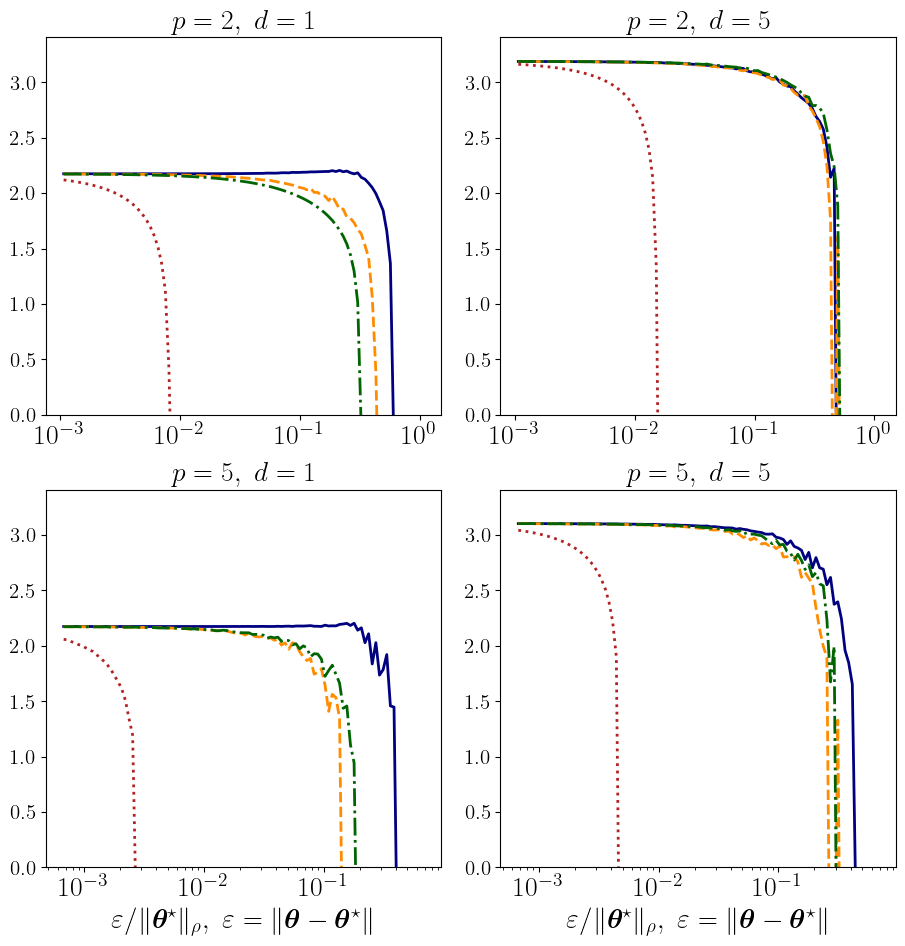

In [162]:
PyPlot.rc("text", usetex = true)
PyPlot.rc("font", family = "serif")
PyPlot.rc("text.latex", preamble = raw"\usepackage{amsmath,amssymb,bm}")

plots = []

max_y = maximum([maximum(projected_hessian_bassins[(p, d)].min_eigval) for (p, d) in Iterators.product(p_range, d_range)])
ymax  = log10(max_y + 1e3)

fig, axs = subplots(2, 2, figsize = (10, 10), constrained_layout = false)
axs = vec(axs)

i = 0
for (p, d) in Iterators.product(p_range, d_range)
	B = projected_hessian_bassins[(p, d)]

	i += 1
	ax = axs[i]

	show_legend = (p == first(p_range) && d == last(d_range))

	ax.set_xscale("log")
	ax.set_ylim(0.0, ymax)
	ax.set_xticks([1e-3, 1e-2, 1e-1, 1e0])

	ax.plot(B.x, signed_log.(B.min_eigval);
		linestyle = "-", color = "navy", linewidth = 2,
	)

	ax.plot(B.x, signed_log.(B.lower_weyl_vp);
		linestyle = "--", color = "darkorange", linewidth = 2,
	)

	ax.plot(B.x, signed_log.(B.lower_env_r);
		linestyle = "-.", color = "darkgreen", linewidth = 2,
	)

	ax.plot(B.x, signed_log.(B.lower_env_proj);
		linestyle = ":", color = "firebrick", linewidth = 2,
	)

	if p == last(p_range)
		ax.set_xlabel(
			L"\varepsilon/\|\bm{\theta}^\star\|_\rho,\ \varepsilon=\|\bm{\theta} - \bm{\theta}^\star\|",
			fontsize = 20,
		)
	end

	ax.set_title(L"p=%$p,\ d=%$d", fontsize = 20)

	ax.tick_params(axis = "x", labelsize = 20)
	ax.tick_params(axis = "y", labelsize = 15)

end

fig.subplots_adjust(left=0.13, right=0.98, bottom=0.12, top=0.95, wspace=0.15, hspace=0.2)

savefig("figures/tsp_var_pro_envelopes.pdf", bbox_inches = "tight")

fig


In [154]:
function basin_data_ranges_vp_noisy_db(
	θ_min, θ_max, ϵ_min, ϵ_max,
	pd_list,
	k_0, k_1, k_2, k_3;
	N = 1000, T = 1.0, Δ = 0.1, N_mc = 100, mc_trials = 1000,
	snr_db::Real = 30.0,
	realizations::Int = 10,
	noise_seed::Int = 1,
	rng = Random.default_rng(),
)
	xgrid = range(-T, T, length = N)
	ϵ = logrange(ϵ_min, ϵ_max, length = N_mc)

	out = Dict{Tuple{Int, Int}, Any}()

	for (p, d) in pd_list
		θ_star = 0.5 * (θ_min + θ_max) * ones(p)
		η_star = ones(p*d)

		dictionary = generate_spike_groups(rng, -T, T, Δ, p, d)
		x_obs_clean = multi_block(k_0, θ_star, dictionary, xgrid) * η_star

		σ_0 = sqrt(p) * lipschitz_constant(k_0, dictionary, xgrid)
		σ_1 = lipschitz_constant(k_1, dictionary, xgrid)
		σ_2 = lipschitz_constant(k_2, dictionary, xgrid)
		σ_3 = lipschitz_constant(k_3, dictionary, xgrid)

		norm_DJ_star =
			opnorm(single_block(k_2, θ_star[1], dictionary[1], xgrid)) *
			norm(η_star, 2) +
			opnorm(single_block(k_1, θ_star[1], dictionary[1], xgrid))

		# storage across realizations
		snrs    = zeros(realizations)
		w_norms = zeros(realizations)

		μmins_vp = zeros(realizations)

		min_eigs_vp = zeros(realizations, N_mc)
		env_vp      = zeros(realizations, N_mc)
		env_r       = zeros(realizations, N_mc)
		env_proj    = zeros(realizations, N_mc)

		for r in 1:realizations
			# --- noise at target SNR ---
			rng_noise = MersenneTwister(noise_seed + r + 10_000*p + d)
			w_dir = randn(rng_noise, length(x_obs_clean))
			w_dir ./= norm(w_dir)

			w_norm = norm(x_obs_clean) * 10.0^(-snr_db/20.0)
			w = w_norm * w_dir
			x_obs_noisy = x_obs_clean + w

			snrs[r]    = 20*log10(norm(x_obs_clean)/norm(w))
			w_norms[r] = norm(w)

			# Functions that depend on x_obs
			H_vp_noisy(θ) = hessian_vp(θ, x_obs_noisy, dictionary, xgrid)
			H_restricted_noisy(θ) = begin
				η = multi_block(k_0, θ, dictionary, xgrid) \ x_obs_clean
				hessian(θ, η, x_obs_noisy, dictionary, xgrid)
			end

			norm_J_star = opnorm(jacobian(θ_star, η_star, dictionary, xgrid))

			μ_min_vp, _ = extrema(eigvals(Hermitian(H_vp_noisy(θ_star))))
			μmins_vp[r] = μ_min_vp

			for (i, δ) in enumerate(ϵ)
				_, min_eigs_vp[r, i] = monte_carlo_extr_spectrum_vp(H_vp_noisy, θ_star, δ; trials = mc_trials)
				env_vp[r, i]         = monte_carlo_envelope_vp(H_vp_noisy, θ_star, δ; trials = mc_trials)
				env_r[r, i]          = monte_carlo_envelope_vp(H_restricted_noisy, θ_star, δ; trials = mc_trials)

				env_proj[r, i] = projected_enveleope(
					δ, norm_J_star, norm_DJ_star, norm(w),
					θ_star, η_star, k_0, x_obs_noisy, σ_0, σ_1, σ_2, σ_3,
					dictionary, xgrid; trials = mc_trials,
				)
			end
		end

		x = ϵ ./ norm(θ_star, 2)

		lower_env_vp   = μmins_vp .- env_vp
		lower_env_r    = μmins_vp .- env_r
		lower_env_proj = μmins_vp .- env_proj

		out[(p, d)] = (
			x = x, snr_db_mean = mean(snrs),
			snr_db_std  = std(snrs),
			w_norm_mean = mean(w_norms),
			w_norm_std  = std(w_norms),
			μ_min_vp_noisy_mean = mean(μmins_vp),
			μ_min_vp_noisy_std  = std(μmins_vp),
			min_eigval_noisy_mean = vec(mean(min_eigs_vp, dims = 1)),
			min_eigval_noisy_std  = vec(std(min_eigs_vp, dims = 1)),
			lower_env_vp_noisy_mean = vec(mean(lower_env_vp, dims = 1)),
			lower_env_vp_noisy_std  = vec(std(lower_env_vp, dims = 1)),
			lower_env_r_noisy_mean = vec(mean(lower_env_r, dims = 1)),
			lower_env_r_noisy_std  = vec(std(lower_env_r, dims = 1)),
			lower_env_proj_noisy_mean = vec(mean(lower_env_proj, dims = 1)),
			lower_env_proj_noisy_std  = vec(std(lower_env_proj, dims = 1)),
		)
	end

	return out
end



basin_data_ranges_vp_noisy_db (generic function with 1 method)

In [155]:
noisy_projected_basin = basin_data_ranges_vp_noisy_db(
	θ_min,
	θ_max,
	1e-4, 
	1e-1,
	pd_list,
	k_0,
	k_1,
	k_2,
	k_3,
	T = 1.0,
	N_mc = 100,
	mc_trials = 10,
	realizations = 10,
	Δ = 5e-3,
	snr_db = 10.0,
);


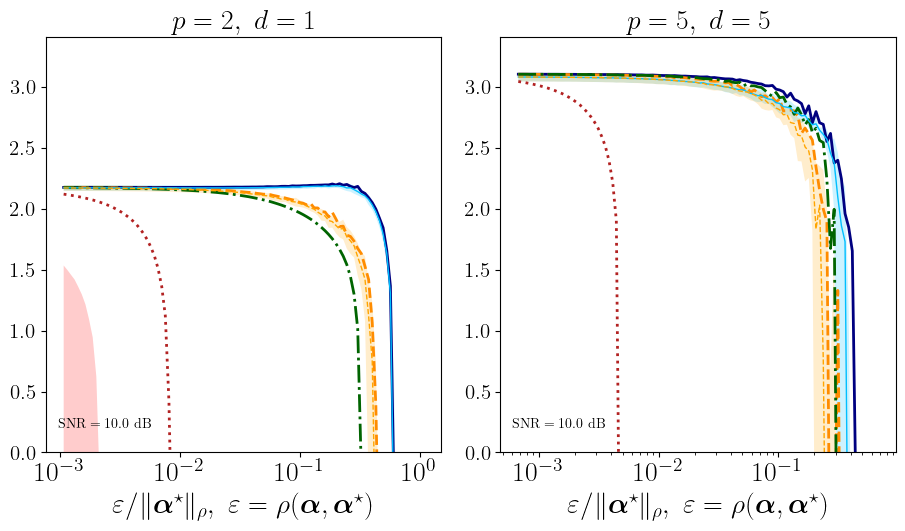

In [158]:
using PyPlot
using LaTeXStrings

PyPlot.rc("text", usetex=true)
PyPlot.rc("font", family="serif")
PyPlot.rc("text.latex", preamble = raw"\usepackage{amsmath,amssymb,bm}")

# --- helper to plot mean + ribbon in signed_log domain ---
function plot_mean_ribbon!(ax, x, m, s; color, ls, lw, label="")
    y  = signed_log.(m)
    yl = signed_log.(m .- s)
    yu = signed_log.(m .+ s)
    ax.plot(x, y; color=color, linestyle=ls, linewidth=lw, label=label)
    ax.fill_between(x, yl, yu; color=color, alpha=0.20, linewidth=0)
end

# ymax: take from the noiseless (projected_hessian_bassins) like you did before
max_y = maximum(maximum(projected_hessian_bassins[(p, d)].min_eigval)
                for (p, d) in Iterators.product(p_range, d_range))
ymax  = log10(max_y + 1e3)

fig, axs = subplots(1, length(pd_list), figsize=(10,5), constrained_layout=false)
axs = length(pd_list) == 1 ? [axs] : vec(axs)

for (idx, (p,d)) in enumerate(pd_list)
    B       = projected_hessian_bassins[(p,d)]     # noiseless
    B_noisy = noisy_projected_basin[(p,d)]         # output of basin_data_ranges_vp_noisy_db (new)

    ax = axs[idx]
    show_legend = (idx == 1)

    ax.set_xscale("log")
	ax.set_ylim(0.0, ymax)
	ax.set_xticks([1e-3, 1e-2, 1e-1, 1e0])

    ax.set_title(L"p=%$p,\ d=%$d", fontsize=20)

    # --- noiseless curves (unchanged) ---
    ax.plot(B.x, signed_log.(B.min_eigval);
		linestyle = "-", color = "navy", linewidth = 2,
	)

	ax.plot(B.x, signed_log.(B.lower_weyl_vp);
		linestyle = "--", color = "darkorange", linewidth = 2,
	)

	ax.plot(B.x, signed_log.(B.lower_env_r);
		linestyle = "-.", color = "darkgreen", linewidth = 2,
	)

	ax.plot(B.x, signed_log.(B.lower_env_proj);
		linestyle = ":", color = "firebrick", linewidth = 2,
	)

    # --- noisy curves from basin_data_ranges_vp_noisy_db ---
    # keys are now:
    #   min_eigval_noisy_mean/std
    #   lower_env_vp_noisy_mean/std
    #   lower_env_r_noisy_mean/std
    #   lower_env_proj_noisy_mean/std

    plot_mean_ribbon!(ax, B_noisy.x, B_noisy.min_eigval_noisy_mean, B_noisy.min_eigval_noisy_std;
        color="deepskyblue", ls="-", lw=1
    )
    plot_mean_ribbon!(ax, B_noisy.x, B_noisy.lower_env_vp_noisy_mean, B_noisy.lower_env_vp_noisy_std;
        color="orange", ls="--", lw=1
    )
    plot_mean_ribbon!(ax, B_noisy.x, B_noisy.lower_env_proj_noisy_mean, B_noisy.lower_env_proj_noisy_std;
        color="red", ls=":", lw=1
    )
    # If you also want the restricted envelope ribbon, uncomment:
    # plot_mean_ribbon!(ax, B_noisy.x, B_noisy.lower_env_r_noisy_mean, B_noisy.lower_env_r_noisy_std;
    #     color="purple", ls="-.", lw=1
    # )

    ax.set_xlabel(L"\varepsilon/\|\bm{\alpha}^\star\|_\rho,\ \varepsilon=\rho(\bm{\alpha},\bm{\alpha}^\star)", fontsize=20)
    
    ax.tick_params(axis="x", labelsize=20)
    ax.tick_params(axis="y", labelsize=15)

    # SNR annotation (new function returns snr_db_mean/std)
    if hasproperty(B_noisy, :snr_db_mean)
        snr_txt = L"\mathrm{SNR}=%$(round(B_noisy.snr_db_mean, digits=1))\ \mathrm{dB}"
        ax.text(0.03, 0.06, snr_txt; transform=ax.transAxes, fontsize=10)
    end

    # if show_legend
    #     ax.legend(loc="lower left", fontsize=15, frameon=true)
    # end
end

fig.subplots_adjust(left=0.13, right=0.98, bottom=0.12, top=0.95, wspace=0.15)

savefig("figures/tsp_projected_hessian_noisy_basin.pdf", bbox_inches="tight") # vector
display(fig)


In [157]:
noisy_projected_basin[(2,1)].lower_env_proj_noisy_mean

100-element Vector{Float64}:
     -40.91095226642402
     -43.6949204726529
     -46.575488266014546
     -49.381440218197
     -52.74795602778222
     -56.119697303273355
     -59.82035726711771
     -63.908122479829025
     -67.87454449252122
     -72.59695182836693
       ⋮
  -80319.34358705653
  -90095.44496063993
 -101210.0683772379
 -113901.33648440559
 -128562.87568968613
 -145369.22552036488
 -164703.64759500607
 -186950.33010609902
 -213045.07748298152